<a href="https://colab.research.google.com/github/Aymanelok/TP_AI/blob/main/TP3_Aymane_AITOUHAMMOU_Arbre_Decision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP 5 — Classification par Arbres de Décision : Modélisation, Évaluation et Élagage

Aymane AITOUHAMMOU
---

## Objectifs pédagogiques

À l'issue de ce travail pratique, l'étudiant sera capable de :

1. **Préparer** un dataset réel pour la classification supervisée (nettoyage, encodage, partitionnement).
2. **Construire** et **évaluer** un arbre de décision avec les critères *Gini* et *Entropie*.
3. **Visualiser** la structure d'un arbre de décision et interpréter ses nœuds de décision.
4. **Optimiser** les hyperparamètres via le pré-élagage (*pre-pruning*) par `GridSearchCV` et par recherche manuelle.
5. **Appliquer** le post-élagage (*post-pruning*) basé sur le chemin de complexité-coût (`ccp_alpha`).
6. **Interpréter** l'importance des variables (*feature importance*) pour formuler des recommandations métier.

---

## Contexte applicatif

Dans ce TP, nous intervenons en tant que data scientists consultants pour une compagnie aérienne fictive, **Invistico Airlines**. L'objectif est de prédire la **satisfaction des passagers** à partir de données d'enquêtes post-vol, et d'identifier les leviers d'action prioritaires pour améliorer l'expérience client.

Le jeu de données comprend **129 880 réponses** de clients et couvre des variables telles que la classe de voyage, la distance du vol, le divertissement à bord, et bien d'autres.

---

## Rappel théorique — L'Arbre de Décision

Un **arbre de décision** est un modèle de classification non paramétrique qui segmente récursivement l'espace des features en régions homogènes. À chaque nœud, l'algorithme sélectionne la variable et le seuil qui maximisent la **pureté** des sous-ensembles résultants.

Deux critères de division sont couramment utilisés :

| Critère | Formule | Caractéristique |
|---|---|---|
| **Indice de Gini** | $G = 1 - \sum_k p_k^2$ | Mesure l'impureté d'un nœud |
| **Entropie** | $H = -\sum_k p_k \log_2(p_k)$ | Mesure l'information à gagner (*information gain*) |

où $p_k$ est la proportion d'observations appartenant à la classe $k$ dans le nœud considéré.

---

## Section 1 — Importation des Bibliothèques

Nous chargeons l'ensemble des bibliothèques nécessaires à l'exécution de ce TP.

In [ ]:
# Bibliothèques standard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Modélisation et évaluation — scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Suppression des avertissements non critiques
warnings.filterwarnings("ignore")

# Style graphique
sns.set_theme(style="whitegrid", palette="muted")

print("✓ Bibliothèques chargées avec succès.")

✓ Bibliothèques chargées avec succès.


---

## Section 2 — Chargement et Exploration du Jeu de Données

### 2.1 Chargement des données

Le fichier `Invistico_Airline.csv` contient les réponses d'enquête de satisfaction de passagers. Nous le chargeons dans un DataFrame Pandas nommé `df_original`.

In [ ]:
df_original = pd.read_csv("C:/Users/ayman/OneDrive/Bureau/M1/archive/invistico_Airline.csv")

print(f"Dimensions du dataset : {df_original.shape[0]:,} observations × {df_original.shape[1]} variables")
df_original.head(10)

Dimensions du dataset : 129,880 observations × 22 variables


,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0
5,satisfied,Loyal Customer,30,Personal Travel,Eco,1894,0,0,0,3,...,2,2,5,4,5,5,4,2,0,0.0
6,satisfied,Loyal Customer,66,Personal Travel,Eco,227,0,0,0,3,...,5,5,5,0,5,5,5,3,17,15.0
7,satisfied,Loyal Customer,10,Personal Travel,Eco,1812,0,0,0,3,...,2,2,3,3,4,5,4,2,0,0.0
8,satisfied,Loyal Customer,56,Personal Travel,Business,73,0,0,0,3,...,5,4,4,0,1,5,4,4,0,0.0
9,satisfied,Loyal Customer,22,Personal Travel,Eco,1556,0,0,0,3,...,2,2,2,4,5,3,4,2,30,26.0


### 2.2 Exploration des types de variables

> **Remarque :** Les arbres de décision scikit-learn n'acceptent que des données **numériques**. Les colonnes de type `object` devront être encodées avant la modélisation.

In [ ]:
print("Types de variables :")
print(df_original.dtypes)

# Résumé des colonnes catégorielles
cat_cols = df_original.select_dtypes(include='object').columns.tolist()
print(f"\nVariables catégorielles ({len(cat_cols)}) : {cat_cols}")

Types de variables :
satisfaction                          object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Seat comfort                           int64
Departure/Arrival time convenient      int64
Food and drink                         int64
Gate location                          int64
Inflight wifi service                  int64
Inflight entertainment                 int64
Online support                         int64
Ease of Online booking                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Online boarding                        int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes          

### 2.3 Analyse de la variable cible

Nous vérifions l'équilibre des classes de la variable cible `satisfaction`. Un déséquilibre marqué peut influencer les métriques d'évaluation et nécessiter des stratégies d'échantillonnage adaptées.

In [ ]:
counts = df_original['satisfaction'].value_counts(dropna=False)
proportions = df_original['satisfaction'].value_counts(normalize=True, dropna=False) * 100

résumé_cible = pd.DataFrame({'Effectif': counts, 'Proportion (%)': proportions.round(1)})
print("Distribution de la variable cible 'satisfaction' :")
print(résumé_cible)
print("\n→ Le dataset est légèrement déséquilibré en faveur des clients satisfaits (~54.7 %).")

Distribution de la variable cible 'satisfaction' :
              Effectif  Proportion (%)
satisfaction                          
satisfied        71087            54.7
dissatisfied     58793            45.3

→ Le dataset est légèrement déséquilibré en faveur des clients satisfaits (~54.7 %).


### 2.4 Analyse de la variable `Class`

La variable `Class` est **ordinale** : les catégories suivent un ordre de valeur croissant (Eco < Eco Plus < Business). Cette propriété justifie un encodage ordinal plutôt qu'un encodage one-hot.

In [ ]:
print("Modalités de la variable 'Class' :", df_original['Class'].unique())
print("\nOrdre croissant de valeur : Eco (1) < Eco Plus (2) < Business (3)")

Modalités de la variable 'Class' : ['Eco' 'Business' 'Eco Plus']

Ordre croissant de valeur : Eco (1) < Eco Plus (2) < Business (3)


---

## Section 3 — Nettoyage et Préparation des Données

### 3.1 Détection des valeurs manquantes

In [ ]:
valeurs_manquantes = df_original.isnull().sum()
print("Nombre de valeurs manquantes par colonne :")
print(valeurs_manquantes[valeurs_manquantes > 0])

total_manquantes = df_original.isnull().sum().sum()
pct_manquantes = total_manquantes / (df_original.shape[0] * df_original.shape[1]) * 100
print(f"\nTotal de valeurs manquantes : {total_manquantes} ({pct_manquantes:.3f}% du dataset)")

Nombre de valeurs manquantes par colonne :
Arrival Delay in Minutes    393
dtype: int64

Total de valeurs manquantes : 393 (0.014% du dataset)


> **Décision de traitement :** La proportion de valeurs manquantes étant très faible (< 0.5 %), la suppression des lignes concernées est une stratégie acceptable. Elle préserve l'intégrité des données sans introduire de biais d'imputation.

In [ ]:
df_subset = df_original.dropna(axis=0).reset_index(drop=True)

n_supprimées = df_original.shape[0] - df_subset.shape[0]
print(f"Lignes supprimées : {n_supprimées}")
print(f"Dimensions après nettoyage : {df_subset.shape}")
print(f"Valeurs manquantes restantes : {df_subset.isnull().sum().sum()}")

Lignes supprimées : 393
Dimensions après nettoyage : (129487, 22)
Valeurs manquantes restantes : 0


### 3.2 Encodage des Variables Catégorielles

Nous appliquons différentes stratégies d'encodage selon la nature de chaque variable :

| Variable | Type | Méthode d'encodage | Valeurs attribuées |
|---|---|---|---|
| `Class` | Ordinale | Encodage manuel (`.map()`) | Eco=1, Eco Plus=2, Business=3 |
| `satisfaction` | Binaire (cible) | Encodage manuel (`.map()`) | dissatisfied=0, satisfied=1 |
| `Customer Type`, `Type of Travel` | Nominale | One-Hot Encoding (`get_dummies`) | Variables indicatrices binaires |

In [ ]:
# Encodage ordinal de la classe de voyage
df_subset['Class'] = df_subset['Class'].map({'Business': 3, 'Eco Plus': 2, 'Eco': 1})

# Encodage binaire de la variable cible
df_subset['satisfaction'] = df_subset['satisfaction'].map({'satisfied': 1, 'dissatisfied': 0})

# Encodage One-Hot des variables nominales restantes
df_subset = pd.get_dummies(df_subset, drop_first=True)

print("Types après encodage :")
print(df_subset.dtypes)
print(f"\nDimensions finales : {df_subset.shape}")

Types après encodage :
satisfaction                           int64
Age                                    int64
Class                                  int64
Flight Distance                        int64
Seat comfort                           int64
Departure/Arrival time convenient      int64
Food and drink                         int64
Gate location                          int64
Inflight wifi service                  int64
Inflight entertainment                 int64
Online support                         int64
Ease of Online booking                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Online boarding                        int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes             float64
Customer Type_disloyal Customer         bool
Type of Travel_Personal Travel  

### 3.3 Partitionnement Train / Test

Nous séparons les données en un ensemble d'entraînement (75 %) et un ensemble de test (25 %), avec une graine aléatoire fixée pour la reproductibilité.

In [ ]:
y = df_subset['satisfaction']
X = df_subset.drop(columns=['satisfaction'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

print(f"Ensemble d'entraînement : {X_train.shape[0]:,} observations ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Ensemble de test        : {X_test.shape[0]:,} observations ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"Nombre de features      : {X.shape[1]}")

Ensemble d'entraînement : 97,115 observations (75%)
Ensemble de test        : 32,372 observations (25%)
Nombre de features      : 21


---

## Section 4 — Modélisation : Arbre de Décision de Base

### 4.1 Entraînement avec le critère Gini (paramètres par défaut)

Nous entraînons un premier arbre de décision sans contrainte de profondeur, ce qui servira de référence (*baseline*) pour les comparaisons ultérieures.

In [ ]:
# Instanciation et entraînement
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=0)
dt_gini.fit(X_train, y_train)

# Prédictions sur le jeu de test
y_pred_gini = dt_gini.predict(X_test)

# Affichage des métriques
print("=" * 45)
print("   Arbre de Décision — Critère : Gini")
print("=" * 45)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_gini):.6f}")
print(f"  Precision : {precision_score(y_test, y_pred_gini):.6f}")
print(f"  Recall    : {recall_score(y_test, y_pred_gini):.6f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_gini):.6f}")
print(f"  Profondeur de l'arbre : {dt_gini.get_depth()}")
print(f"  Nombre de feuilles    : {dt_gini.get_n_leaves()}")

   Arbre de Décision — Critère : Gini
  Accuracy  : 0.935438
  Precision : 0.942859
  Recall    : 0.939030
  F1-Score  : 0.940940
  Profondeur de l'arbre : 34
  Nombre de feuilles    : 4653


### 4.2 Matrice de Confusion

La matrice de confusion permet d'analyser qualitativement les erreurs de classification :

| | Prédit : 0 | Prédit : 1 |
|---|---|---|
| **Réel : 0** | Vrais Négatifs (TN) | Faux Positifs (FP) |
| **Réel : 1** | Faux Négatifs (FN) | Vrais Positifs (TP) |

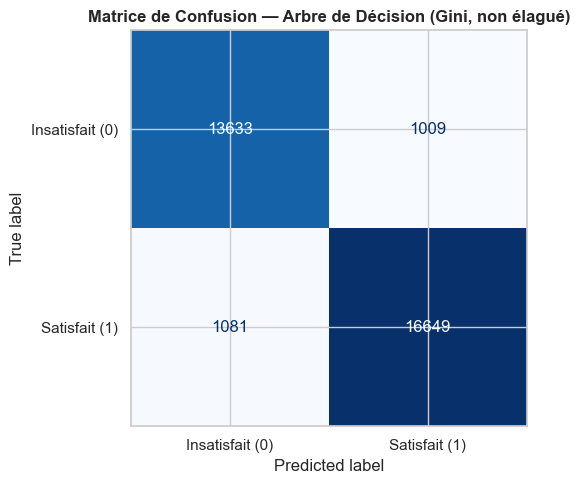

Vrais Positifs  : 16,649  |  Vrais Négatifs : 13,633
Faux Positifs   : 1,009   |  Faux Négatifs  : 1,081


In [ ]:
cm = confusion_matrix(y_test, y_pred_gini, labels=dt_gini.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Insatisfait (0)', 'Satisfait (1)'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title("Matrice de Confusion — Arbre de Décision (Gini, non élagué)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Vrais Positifs  : {tp:,}  |  Vrais Négatifs : {tn:,}")
print(f"Faux Positifs   : {fp:,}   |  Faux Négatifs  : {fn:,}")

### 4.3 Visualisation de l'Arbre (profondeur max = 2)

Nous limitons l'affichage à une profondeur de 2 pour conserver la lisibilité. Chaque nœud indique : la condition de séparation, l'impureté Gini, le nombre d'échantillons et la distribution des classes.

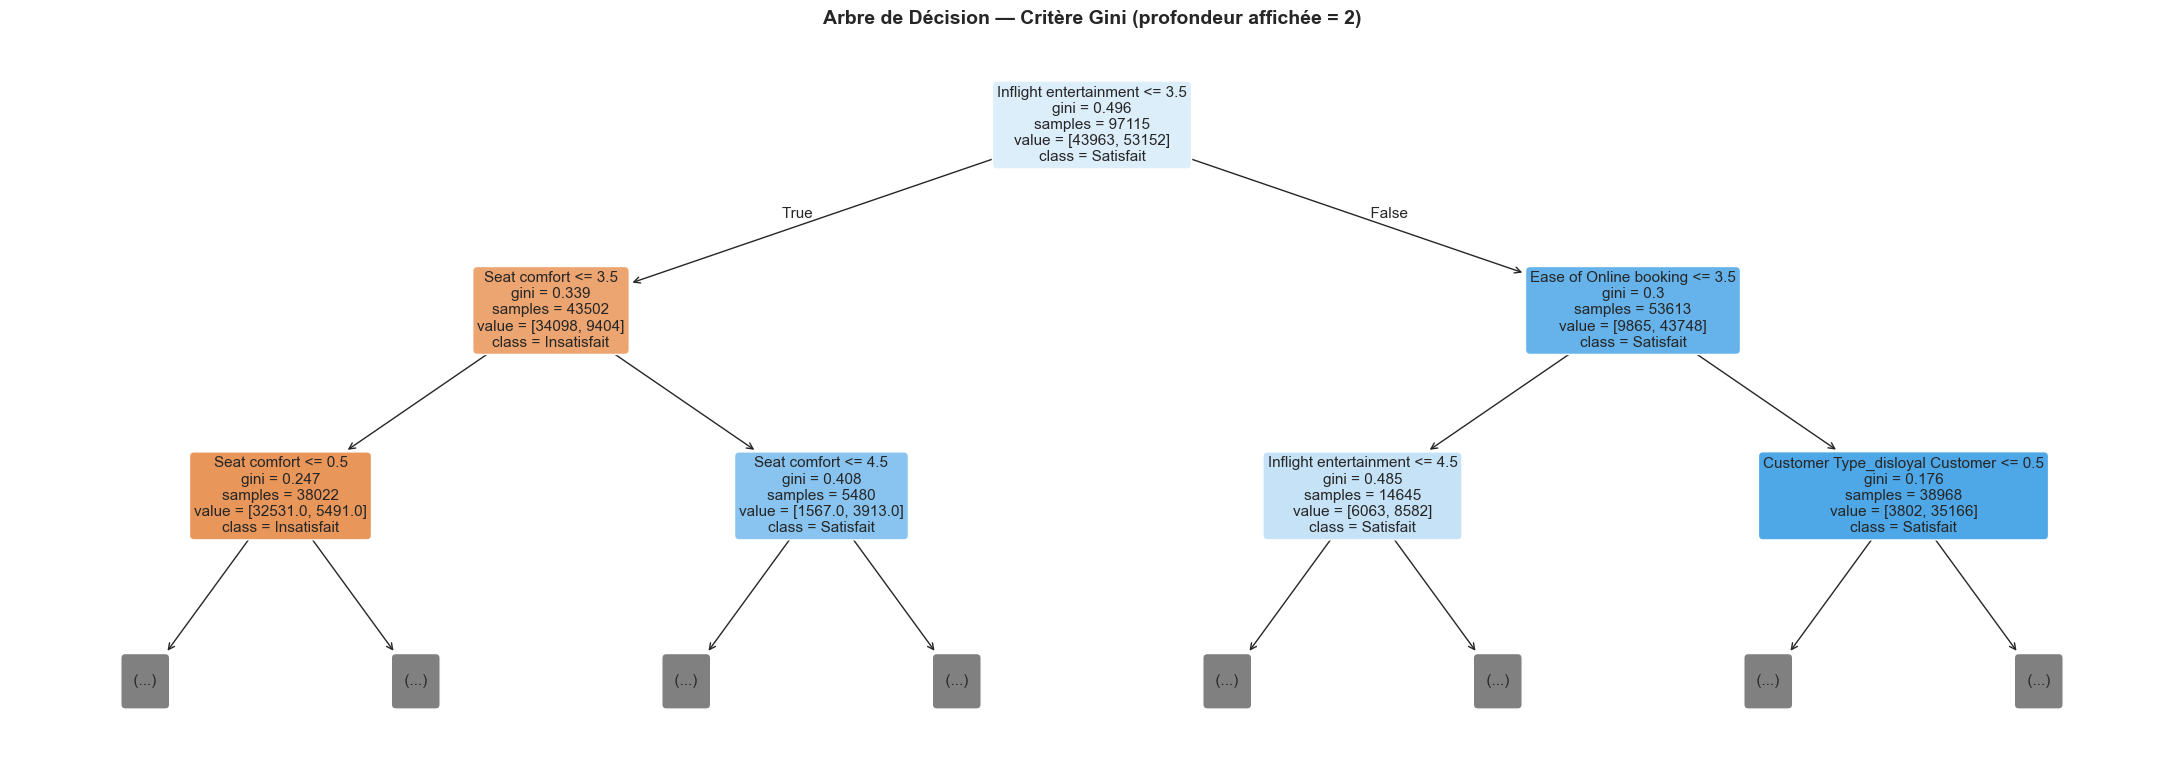

In [ ]:
plt.figure(figsize=(22, 8))
plot_tree(
    dt_gini,
    max_depth=2,
    fontsize=11,
    feature_names=X.columns,
    class_names=['Insatisfait', 'Satisfait'],
    filled=True,
    rounded=True,
    impurity=True
)
plt.title("Arbre de Décision — Critère Gini (profondeur affichée = 2)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.4 Comparaison des Critères : Gini vs Entropie

Nous entraînons un second arbre avec le critère **Entropie** pour comparer les performances obtenues.

In [ ]:
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=0)
dt_entropy.fit(X_train, y_train)
y_pred_entropy = dt_entropy.predict(X_test)

# Tableau comparatif
comparaison = pd.DataFrame({
    'Critère'   : ['Gini', 'Entropie'],
    'Accuracy'  : [accuracy_score(y_test, y_pred_gini),    accuracy_score(y_test, y_pred_entropy)],
    'Precision' : [precision_score(y_test, y_pred_gini),   precision_score(y_test, y_pred_entropy)],
    'Recall'    : [recall_score(y_test, y_pred_gini),      recall_score(y_test, y_pred_entropy)],
    'F1-Score'  : [f1_score(y_test, y_pred_gini),          f1_score(y_test, y_pred_entropy)],
    'Profondeur': [dt_gini.get_depth(),                    dt_entropy.get_depth()]
}).set_index('Critère').round(6)

print("Comparaison Gini vs Entropie (sans élagage) :")
comparaison

Comparaison Gini vs Entropie (sans élagage) :


,Accuracy,Precision,Recall,F1-Score,Profondeur
Critère,,,,,
Gini,0.935438,0.942859,0.939030,0.940940,34
Entropie,0.937137,0.943086,0.942076,0.942581,40


> **Analyse :** En l'absence d'élagage, les deux critères produisent généralement des performances similaires. La différence principale se manifeste dans la structure interne de l'arbre. L'entropie a tendance à créer des arbres légèrement plus profonds mais avec des nœuds plus purs.

---

## Section 5 — Optimisation des Hyperparamètres : Pré-élagage (*Pre-pruning*)

### 5.1 Pourquoi élaguer ?

Un arbre sans contrainte croît jusqu'à séparer parfaitement le jeu d'entraînement, ce qui conduit au **sur-apprentissage** (*overfitting*) : le modèle mémorise le bruit au lieu d'apprendre des patterns généralisables. L'élagage contraint la croissance de l'arbre pour améliorer sa capacité de généralisation.

| Hyperparamètre | Rôle |
|---|---|
| `max_depth` | Profondeur maximale de l'arbre |
| `min_samples_leaf` | Nombre minimal d'échantillons requis dans une feuille |
| `min_samples_split` | Nombre minimal d'échantillons pour diviser un nœud |
| `criterion` | Critère de division (Gini ou Entropie) |

### 5.2 Pré-élagage par `GridSearchCV`

In [ ]:
# Définition de la grille d'hyperparamètres
grille_params = {
    'criterion'        : ['gini', 'entropy'],
    'max_depth'        : list(range(1, 5)),
    'min_samples_leaf' : list(range(1, 3)),
    'min_samples_split': list(range(2, 3))
}

clf_base = DecisionTreeClassifier(random_state=0)

# Recherche par validation croisée (optimisation du F1-Score)
grid_search = GridSearchCV(
    estimator=clf_base,
    param_grid=grille_params,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    error_score='raise'
)

grid_search.fit(X_train, y_train)

print("Meilleurs hyperparamètres identifiés :")
for param, valeur in grid_search.best_params_.items():
    print(f"  {param:25s} : {valeur}")
print(f"\nMeilleur F1-Score (validation croisée) : {grid_search.best_score_:.6f}")

Meilleurs hyperparamètres identifiés :
  criterion                 : gini
  max_depth                 : 4
  min_samples_leaf          : 1
  min_samples_split         : 2

Meilleur F1-Score (validation croisée) : 0.876390


In [ ]:
# Entraînement du modèle optimal
clf_pruned_grid = DecisionTreeClassifier(
    criterion        = grid_search.best_params_['criterion'],
    max_depth        = grid_search.best_params_['max_depth'],
    min_samples_leaf = grid_search.best_params_['min_samples_leaf'],
    min_samples_split= grid_search.best_params_['min_samples_split'],
    random_state=0
)
clf_pruned_grid.fit(X_train, y_train)
y_pred_grid = clf_pruned_grid.predict(X_test)

print("=" * 50)
print("   Pré-élagage — GridSearchCV (meilleurs params)")
print("=" * 50)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_grid):.6f}")
print(f"  Precision : {precision_score(y_test, y_pred_grid):.6f}")
print(f"  Recall    : {recall_score(y_test, y_pred_grid):.6f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_grid):.6f}")
print(f"  Profondeur finale : {clf_pruned_grid.get_depth()}")

   Pré-élagage — GridSearchCV (meilleurs params)
  Accuracy  : 0.867046
  Precision : 0.909529
  Recall    : 0.840891
  F1-Score  : 0.873864
  Profondeur finale : 4


### 5.3 Pré-élagage par Recherche Manuelle — Courbe Accuracy vs `max_depth`

Une approche alternative consiste à tracer la courbe de performance en fonction de la profondeur maximale, afin d'identifier visuellement le point de compromis biais-variance optimal.

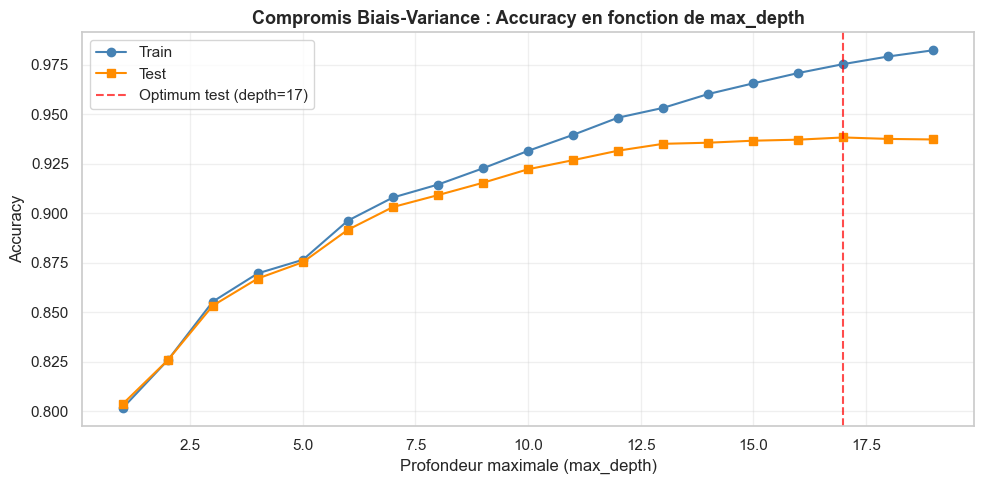

Profondeur optimale identifiée : 17  (Accuracy test = 0.938311)


In [ ]:
profondeurs = range(1, 20)
accuracy_train = []
accuracy_test  = []

for depth in profondeurs:
    clf_temp = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=0)
    clf_temp.fit(X_train, y_train)
    accuracy_train.append(accuracy_score(y_train, clf_temp.predict(X_train)))
    accuracy_test.append(accuracy_score(y_test, clf_temp.predict(X_test)))

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(profondeurs, accuracy_train, 'o-', label='Train', color='steelblue')
ax.plot(profondeurs, accuracy_test,  's-', label='Test',  color='darkorange')
ax.axvline(x=profondeurs[accuracy_test.index(max(accuracy_test))],
           color='red', linestyle='--', alpha=0.7,
           label=f'Optimum test (depth={profondeurs[accuracy_test.index(max(accuracy_test))]})')
ax.set_xlabel('Profondeur maximale (max_depth)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Compromis Biais-Variance : Accuracy en fonction de max_depth', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_depth = profondeurs[accuracy_test.index(max(accuracy_test))]
print(f"Profondeur optimale identifiée : {best_depth}  (Accuracy test = {max(accuracy_test):.6f})")

> **Interprétation :** La courbe de train continue de croître avec la profondeur (sur-apprentissage progressif), tandis que la courbe de test plafonne puis peut légèrement décliner. La profondeur optimale se situe là où l'écart entre les deux courbes commence à se creuser significativement.

In [ ]:
# Entraînement avec la profondeur optimale identifiée manuellement
clf_manual = DecisionTreeClassifier(criterion='gini', max_depth=best_depth, random_state=0)
clf_manual.fit(X_train, y_train)
y_pred_manual = clf_manual.predict(X_test)

print(f"=" * 50)
print(f"   Pré-élagage Manuel (max_depth = {best_depth})")
print(f"=" * 50)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_manual):.6f}")
print(f"  Precision : {precision_score(y_test, y_pred_manual):.6f}")
print(f"  Recall    : {recall_score(y_test, y_pred_manual):.6f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_manual):.6f}")

   Pré-élagage Manuel (max_depth = 17)
  Accuracy  : 0.938311
  Precision : 0.951035
  Recall    : 0.935533
  F1-Score  : 0.943220


---

## Section 6 — Post-élagage (*Post-pruning*) par Chemin de Complexité-Coût

### 6.1 Principe du Post-élagage

Le post-élagage intervient **après** l'entraînement d'un arbre complet. Il consiste à supprimer des sous-arbres dont la contribution à la réduction d'impureté est jugée insuffisante au regard de la complexité ajoutée.

Le paramètre `ccp_alpha` ($\alpha$) contrôle cette complexité-coût. L'objectif est de minimiser :

$$\text{Coût}(T) = R(T) + \alpha \cdot |T|$$

où $R(T)$ est l'erreur de l'arbre $T$ et $|T|$ son nombre de feuilles terminales. Plus $\alpha$ est grand, plus l'arbre est élagué.

### 6.2 Calcul du Chemin de Pruning

Nombre de valeurs ccp_alpha candidates : 2023
Plage : [0.000000, 0.177943]


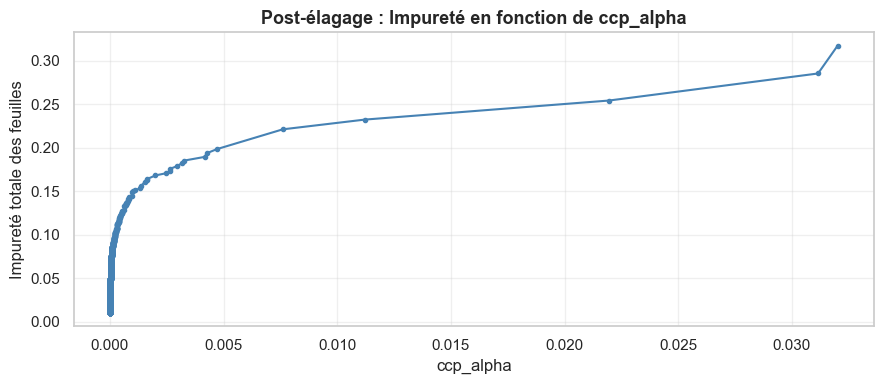

In [ ]:
# Entraîner un arbre profond comme point de départ
clf_full = DecisionTreeClassifier(max_depth=23, random_state=0)

# Obtenir tous les alpha possibles le long du chemin de pruning
path = clf_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

print(f"Nombre de valeurs ccp_alpha candidates : {len(ccp_alphas)}")
print(f"Plage : [{ccp_alphas.min():.6f}, {ccp_alphas.max():.6f}]")

# Visualisation de l'impureté totale en fonction d'alpha
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ccp_alphas[:-1], impurities[:-1], 'o-', color='steelblue', markersize=3)
ax.set_xlabel('ccp_alpha', fontsize=12)
ax.set_ylabel('Impureté totale des feuilles', fontsize=12)
ax.set_title('Post-élagage : Impureté en fonction de ccp_alpha', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3 Sélection de l'Alpha Optimal par `GridSearchCV`

In [ ]:
clf_post = DecisionTreeClassifier(max_depth=23, random_state=0)

grille_alpha = {'ccp_alpha': ccp_alphas}

grid_search_post = GridSearchCV(
    estimator=clf_post,
    param_grid=grille_alpha,
    scoring='f1',
    cv=5,
    n_jobs=-1
)
grid_search_post.fit(X_train, y_train)

best_alpha = grid_search_post.best_params_['ccp_alpha']
print(f"Alpha optimal : {best_alpha:.8f}")
print(f"Meilleur F1 (validation croisée) : {grid_search_post.best_score_:.6f}")

Alpha optimal : 0.00004046
Meilleur F1 (validation croisée) : 0.949130


In [ ]:
# Évaluation du modèle post-élagué optimal
clf_best_post = grid_search_post.best_estimator_
y_pred_post = clf_best_post.predict(X_test)

print("=" * 50)
print("   Post-élagage — ccp_alpha optimal")
print("=" * 50)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_post):.6f}")
print(f"  Precision : {precision_score(y_test, y_pred_post):.6f}")
print(f"  Recall    : {recall_score(y_test, y_pred_post):.6f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_post):.6f}")
print(f"  Profondeur finale : {clf_best_post.get_depth()}")
print(f"  Nombre de feuilles : {clf_best_post.get_n_leaves()}")

   Post-élagage — ccp_alpha optimal
  Accuracy  : 0.944087
  Precision : 0.959425
  Recall    : 0.937563
  F1-Score  : 0.948368
  Profondeur finale : 22
  Nombre de feuilles : 554


---

## Section 7 — Synthèse Comparative des Modèles

In [ ]:
def métriques(y_true, y_pred, label):
    return {
        'Modèle'    : label,
        'Accuracy'  : round(accuracy_score(y_true, y_pred), 4),
        'Precision' : round(precision_score(y_true, y_pred), 4),
        'Recall'    : round(recall_score(y_true, y_pred), 4),
        'F1-Score'  : round(f1_score(y_true, y_pred), 4),
    }

synthèse = pd.DataFrame([
    métriques(y_test, y_pred_gini,    'Baseline (Gini, sans élagage)'),
    métriques(y_test, y_pred_entropy, 'Baseline (Entropie, sans élagage)'),
    métriques(y_test, y_pred_grid,    'Pré-élagage GridSearchCV'),
    métriques(y_test, y_pred_manual,  f'Pré-élagage Manuel (depth={best_depth})'),
    métriques(y_test, y_pred_post,    'Post-élagage (ccp_alpha optimal)'),
]).set_index('Modèle')

print("Tableau comparatif des performances sur le jeu de test :")
synthèse.style.highlight_max(color='lightgreen', axis=0)

Tableau comparatif des performances sur le jeu de test :


,Accuracy,Precision,Recall,F1-Score
Modèle,,,,
"Baseline (Gini, sans élagage)",0.935400,0.942900,0.939000,0.940900
"Baseline (Entropie, sans élagage)",0.937100,0.943100,0.942100,0.942600
Pré-élagage GridSearchCV,0.867000,0.909500,0.840900,0.873900
Pré-élagage Manuel (depth=17),0.938300,0.951000,0.935500,0.943200
Post-élagage (ccp_alpha optimal),0.944100,0.959400,0.937600,0.948400


---

## Section 8 — Importance des Variables (*Feature Importance*)

### 8.1 Interprétation

L'attribut `feature_importances_` de `DecisionTreeClassifier` quantifie la contribution de chaque variable à la réduction totale de l'impureté (Gini ou Entropie) au sein de l'arbre. Il est calculé comme suit :

$$\text{Importance}(x_j) = \frac{\sum_{t \in T_j} n_t \cdot \Delta I(t)}{\sum_{t \in T} n_t \cdot \Delta I(t)}$$

où $T_j$ est l'ensemble des nœuds divisant sur la variable $x_j$, $n_t$ le nombre d'échantillons dans le nœud $t$, et $\Delta I(t)$ la réduction d'impureté au nœud $t$.

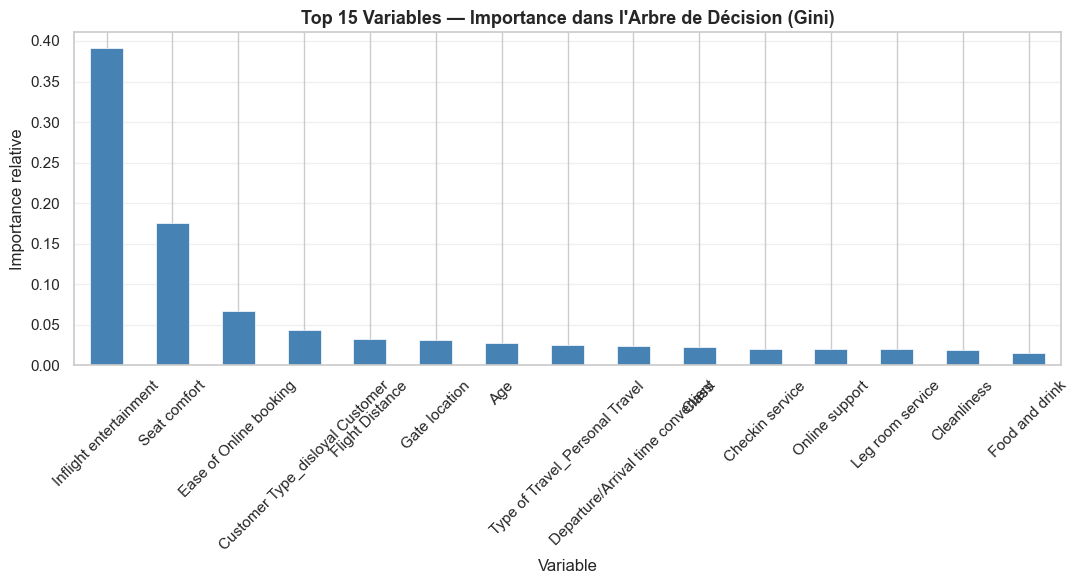


Top 5 variables les plus importantes :
  Inflight entertainment              : 0.3911 (39.1%)
  Seat comfort                        : 0.1755 (17.6%)
  Ease of Online booking              : 0.0667 (6.7%)
  Customer Type_disloyal Customer     : 0.0440 (4.4%)
  Flight Distance                     : 0.0318 (3.2%)


In [ ]:
# Calcul et tri des importances
importances = pd.Series(
    dt_gini.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Affichage des 15 variables les plus importantes
top_n = 15
fig, ax = plt.subplots(figsize=(11, 6))
importances.head(top_n).plot.bar(ax=ax, color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Variable', fontsize=12)
ax.set_ylabel('Importance relative', fontsize=12)
ax.set_title(f'Top {top_n} Variables — Importance dans l\'Arbre de Décision (Gini)', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTop 5 variables les plus importantes :")
for var, imp in importances.head(5).items():
    print(f"  {var:35s} : {imp:.4f} ({imp*100:.1f}%)")

---

## Section 9 — Conclusions et Recommandations

### 9.1 Synthèse des enseignements

| Aspect | Observation |
|---|---|
| **Performance baseline** | L'arbre non élagué atteint une haute accuracy mais risque le sur-apprentissage |
| **Gini vs Entropie** | Les deux critères donnent des résultats similaires sur ce dataset |
| **Pré-élagage** | La contrainte `max_depth` réduit le sur-apprentissage et simplifie l'arbre |
| **Post-élagage** | L'optimisation de `ccp_alpha` offre un contrôle fin du compromis biais-variance |
| **Feature importance** | Les variables les plus discriminantes sont celles liées à l'expérience à bord |
